# LightGBM vs XGBoost 비교 실습

In [1]:
# import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 모델
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [2]:
# 데이터 불러오기
housing = fetch_california_housing()

X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target)

In [3]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state=45
)

In [4]:
# 모델 정의
# XGBoost 모델
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)


# LightGBM 모델
lgb_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
    

In [5]:
# 모델 학습
# XGBoost 학습
xgb_model.fit(X_train, y_train)

# LightGBM 학습
lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000609 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 2.065995


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [6]:
# 예측 수행
xgb_pred = xgb_model.predict(X_test)
lgb_pred = lgb_model.predict(X_test)

In [10]:
# 모델 성능 평가 함수 정의
def evaluate(y_train, y_pred):
    mae = mean_absolute_error(y_train, y_pred)
    rmse = np.sqrt(mean_squared_error(y_train, y_pred))
    r2 = r2_score(y_train, y_pred)

    return mae, rmse, r2

# 성능 계산
xgb_mae, xgb_rmse, xgb_r2 = evaluate(y_test, xgb_pred)
lgb_mae, lgb_rmse, lgb_r2 = evaluate(y_test, xgb_pred)

# 출력
print("====== XGBoost 성능 ======")
print(f"MAE : {xgb_mae:.4f}")
print(f"RMSE : {xgb_rmse:.4f}")
print(f"R2 : {xgb_r2:.4f}")

print("====== LGBM 성능 ======")
print(f"MAE : {lgb_mae:.4f}")
print(f"RMSE : {lgb_rmse:.4f}")
print(f"R2 : {lgb_r2:.4f}")



====== XGBoost 성능 ======
MAE : 0.3114
RMSE : 0.4594
R2 : 0.8409
====== LGBM 성능 ======
MAE : 0.3114
RMSE : 0.4594
R2 : 0.8409


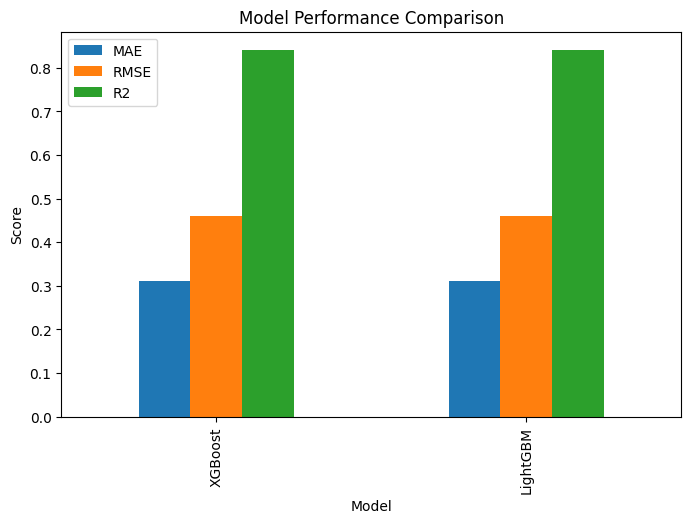

In [11]:
# 성능 비교 시각화
# 비교용 데이터 프레임 생성
results = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM"],
    "MAE": [xgb_mae, lgb_mae],
    "RMSE": [xgb_rmse, lgb_rmse],
    "R2": [xgb_r2, lgb_r2]
})

# 막대 그래프 시각화
results.set_index("Model").plot(kind="bar", figsize=(8,5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()

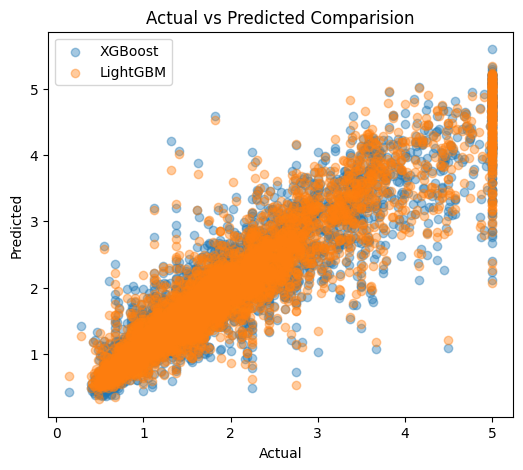

In [14]:
# 실제값 vs 예측값 성능 비교
plt.figure(figsize=(6,5))

# XGBoost
plt.scatter(y_test, xgb_pred, alpha=0.4, label="XGBoost")

# LightGBM
plt.scatter(y_test, lgb_pred, alpha=0.4, label="LightGBM")

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Comparision")
plt.legend()
plt.show()

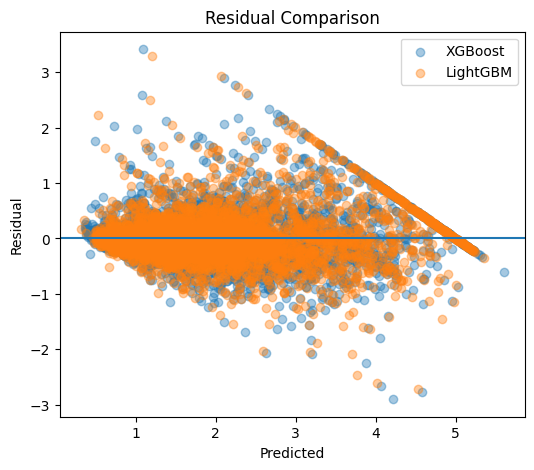

In [16]:
# 잔차 비교
xgb_residual = y_test - xgb_pred
lgb_residual = y_test - lgb_pred

plt.figure(figsize=(6,5))

# XGBoost
plt.scatter(xgb_pred, xgb_residual, alpha=0.4, label="XGBoost")

# LightGBM
plt.scatter(lgb_pred, lgb_residual, alpha=0.4, label="LightGBM")

plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Comparison")
plt.legend()
plt.show()


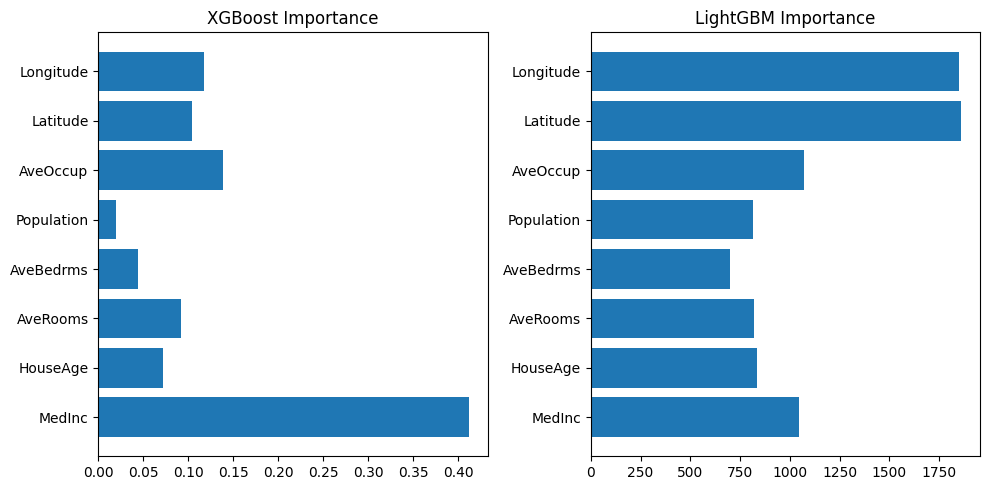

In [17]:
# feature importance 비교

# XGBoost 중요도
xgb_importance = xgb_model.feature_importances_

# LightGBM 중요도
lgb_importance = lgb_model.feature_importances_

# 그래프
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.barh(X.columns, xgb_importance)
plt.title("XGBoost Importance")

plt.subplot(1,2,2)
plt.barh(X.columns, lgb_importance)
plt.title("LightGBM Importance")

plt.tight_layout()
plt.show()